In [1]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

2025/11/04 15:01:55 INFO mlflow.tracking.fluent: Experiment with name 'Chicago_Crime_Clustering' does not exist. Creating a new experiment.
2025/11/04 16:10:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/04 16:10:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ K-Means Model Trained and Logged to MLflow
Optimal Clusters: 7
Silhouette Score: 0.1748
Model saved as models/kmeans_model.pkl


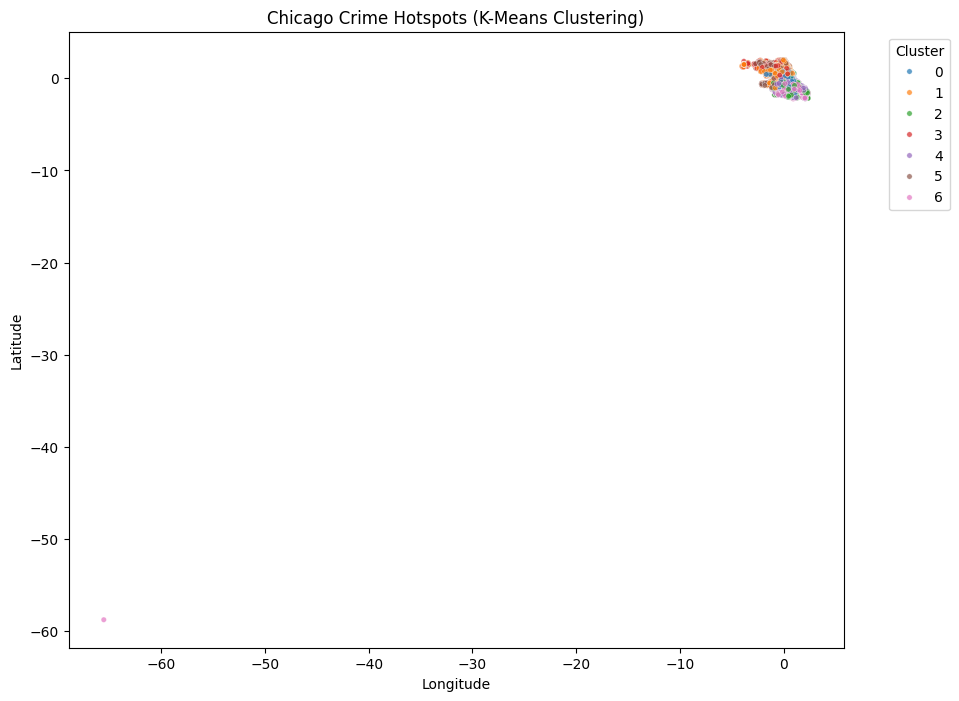

In [2]:
# --- 1. Load final dataset ---
df = pd.read_csv("chicago_final_data.csv")

# --- 2. Select key features for clustering ---
features = ['Latitude', 'Longitude', 'hour', 'month', 'severity_score']
data = df[features]

# --- 3. Scale features ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# --- 4. Set up MLflow experiment ---
mlflow.set_experiment("Chicago_Crime_Clustering")

with mlflow.start_run(run_name="KMeans_GeoCrime_Hotspots"):
    
    # --- 5. Determine optimal number of clusters using elbow method ---
    inertia = []
    K = range(3, 11)
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(scaled_data)
        inertia.append(km.inertia_)
    
    plt.figure(figsize=(8, 4))
    plt.plot(K, inertia, 'o-', color='blue')
    plt.title("Elbow Method for Optimal K")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.savefig("elbow_plot.png")
    plt.close()

    # --- 6. Train final KMeans model ---
    optimal_k = 7  # You can adjust based on elbow curve visually
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)
    df['Cluster'] = cluster_labels

    # --- 7. Evaluate model ---
    sil_score = silhouette_score(scaled_data, cluster_labels)
    
    # --- 8. Log parameters and metrics to MLflow ---
    mlflow.log_param("algorithm", "KMeans")
    mlflow.log_param("n_clusters", optimal_k)
    mlflow.log_param("features_used", features)
    mlflow.log_metric("silhouette_score", sil_score)
    
    # --- 9. Log artifacts (plots + model) ---
    mlflow.log_artifact("elbow_plot.png")
    
    # --- 10. Save trained model and scaler for Streamlit ---
    os.makedirs("models", exist_ok=True)
    joblib.dump(kmeans, "models/kmeans_model.pkl")
    joblib.dump(scaler, "models/scaler.pkl")
    mlflow.sklearn.log_model(kmeans, "model")
    
    print(f"✅ K-Means Model Trained and Logged to MLflow")
    print(f"Optimal Clusters: {optimal_k}")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Model saved as models/kmeans_model.pkl")

# --- 11. Visualize Clusters ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Longitude', y='Latitude',
    hue='Cluster', palette='tab10',
    data=df.sample(20000, random_state=42),
    s=15, alpha=0.7
)
plt.title("Chicago Crime Hotspots (K-Means Clustering)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
#K Means
# --- Set MLflow experiment name ---
mlflow.set_experiment("Chicago_Crime_Clustering")

# --- Load dataset ---
df = pd.read_csv("chicago_crime_cleaned.csv")

# --- Select features (removed severity_score) ---
features = ['Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate']
X = df[features].dropna()

# --- Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Define cluster count ---
n_clusters = 5  # ✅ Using 5 clusters now

# --- Start MLflow run ---
with mlflow.start_run(run_name="KMeans_GeoClustering_v3") as run:
    # Log parameters
    mlflow.log_param("n_clusters", n_clusters)
    mlflow.log_param("features_used", features)

    # --- Train K-Means model ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # --- Evaluate cluster quality ---
    silhouette = silhouette_score(X_scaled, cluster_labels)
    mlflow.log_metric("silhouette_score", silhouette)

    # --- Save model & scaler ---
    joblib.dump(kmeans, "kmeans_geo_model_v3.pkl")
    joblib.dump(scaler, "geo_scaler_v3.pkl")

    # Log artifacts to MLflow
    mlflow.log_artifact("kmeans_geo_model_v3.pkl")
    mlflow.log_artifact("geo_scaler_v3.pkl")

    # --- Save cluster-labeled dataset for Streamlit visualization ---
    df["cluster"] = cluster_labels
    df.to_csv("chicago_kmeans_clustered_v3.csv", index=False)
    mlflow.log_artifact("chicago_kmeans_clustered_v3.csv")

    print(f"✅ Run logged in MLflow experiment 'Chicago_Crime_Clustering'")
    print(f"Clusters: {n_clusters} | Silhouette Score: {silhouette:.4f}")


✅ Run logged in MLflow experiment 'Chicago_Crime_Clustering'
Clusters: 5 | Silhouette Score: 0.3519


In [1]:
##DB Scan
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pickle
import time

# --- Load cleaned data ---
df = pd.read_csv("chicago_crime_cleaned.csv")
features = ['Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate']
X = df[features].dropna()

# --- Take manageable sample (for speed) ---
sample_size = 30000
X_sample = X.sample(n=sample_size, random_state=42).reset_index(drop=True)

# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# --- MLflow setup ---
mlflow.set_experiment("Chicago_Crime_Clustering")

best_model = None
best_score = -1
best_params = None

# --- Parameter grid (small for speed) ---
eps_values = [0.2, 0.3, 0.4]
min_samples_values = [30, 50, 70]

with mlflow.start_run(run_name="DBSCAN_Geographic_AutoTune") as run:
    for eps in eps_values:
        for min_s in min_samples_values:
            print(f"\n⏳ Training DBSCAN (eps={eps}, min_samples={min_s}) ...")
            start = time.time()
            
            # Train
            model = DBSCAN(eps=eps, min_samples=min_s, n_jobs=-1)
            labels = model.fit_predict(X_scaled)
            mask = labels != -1
            
            # Evaluate
            if len(np.unique(labels[mask])) > 1:
                sil = silhouette_score(X_scaled[mask], labels[mask])
                dbi = davies_bouldin_score(X_scaled[mask], labels[mask])
            else:
                sil, dbi = -1, -1
            
            duration = time.time() - start
            clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
            
            print(f"✅ Done in {duration:.1f}s | Clusters: {clusters} | Silhouette: {sil:.4f}")

            # Log to MLflow
            mlflow.log_metric(f"silhouette_eps{eps}_min{min_s}", sil)
            mlflow.log_metric(f"davies_eps{eps}_min{min_s}", dbi)
            mlflow.log_metric(f"time_eps{eps}_min{min_s}", duration)
            
            # Keep best
            if sil > best_score:
                best_score = sil
                best_model = model
                best_params = (eps, min_s)
    
    # --- Save the best model ---
    eps_best, min_s_best = best_params
    print(f"\n🏆 Best model: eps={eps_best}, min_samples={min_s_best} | Silhouette={best_score:.4f}")

    model_filename = "dbscan_geo_model_v3.pkl"
    scaler_filename = "geo_scaler_v3.pkl"
    
    with open(model_filename, "wb") as f:
        pickle.dump(best_model, f)
    with open(scaler_filename, "wb") as f:
        pickle.dump(scaler, f)
    
    # Log final artifacts
    mlflow.log_param("best_eps", eps_best)
    mlflow.log_param("best_min_samples", min_s_best)
    mlflow.log_metric("best_silhouette_score", best_score)
    mlflow.log_artifact(model_filename)
    mlflow.log_artifact(scaler_filename)
    mlflow.log_artifact("chicago_crime_cleaned.csv")

    print("\n🎯 Auto-tuned DBSCAN model saved & logged successfully!")



⏳ Training DBSCAN (eps=0.2, min_samples=30) ...
✅ Done in 28.6s | Clusters: 4 | Silhouette: 0.1773

⏳ Training DBSCAN (eps=0.2, min_samples=50) ...
✅ Done in 22.7s | Clusters: 2 | Silhouette: 0.5706

⏳ Training DBSCAN (eps=0.2, min_samples=70) ...
✅ Done in 19.9s | Clusters: 6 | Silhouette: -0.0542

⏳ Training DBSCAN (eps=0.3, min_samples=30) ...
✅ Done in 21.8s | Clusters: 2 | Silhouette: 0.5553

⏳ Training DBSCAN (eps=0.3, min_samples=50) ...
✅ Done in 22.4s | Clusters: 2 | Silhouette: 0.5597

⏳ Training DBSCAN (eps=0.3, min_samples=70) ...
✅ Done in 20.9s | Clusters: 2 | Silhouette: 0.5633

⏳ Training DBSCAN (eps=0.4, min_samples=30) ...
✅ Done in 20.9s | Clusters: 2 | Silhouette: 0.5553

⏳ Training DBSCAN (eps=0.4, min_samples=50) ...
✅ Done in 19.5s | Clusters: 2 | Silhouette: 0.5553

⏳ Training DBSCAN (eps=0.4, min_samples=70) ...
✅ Done in 21.1s | Clusters: 2 | Silhouette: 0.5569

🏆 Best model: eps=0.2, min_samples=50 | Silhouette=0.5706

🎯 Auto-tuned DBSCAN model saved & logge

Loading data and scaler...
Clusters=4, Silhouette=0.3863
Clusters=5, Silhouette=0.3490
Clusters=6, Silhouette=0.3398
Clusters=7, Silhouette=0.3439
Clusters=8, Silhouette=0.3721
✅ Best model saved with 4 clusters | Silhouette=0.3863
Generating dendrogram on 500-sample subset for visualization...


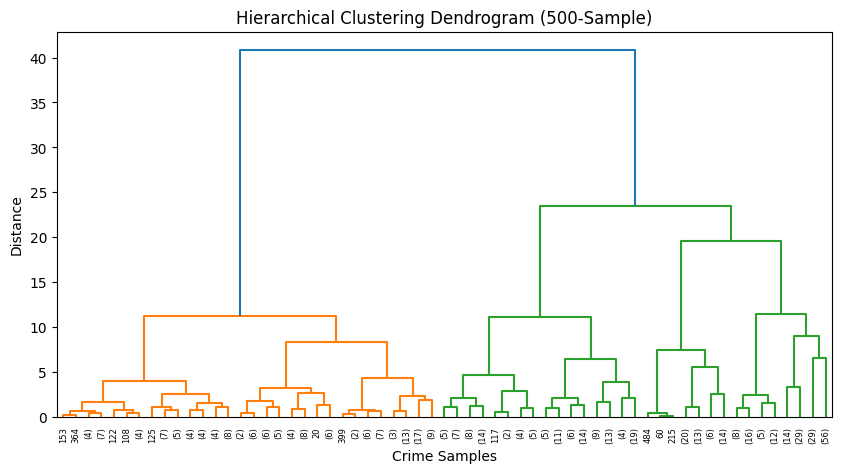

In [3]:
# --- Hierarchical Clustering with Sampling (Optimized for Large Data) ---
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pickle
import random

# --- 1. Load Data & Scaler ---
print("Loading data and scaler...")
df = pd.read_csv("chicago_crime_cleaned.csv")
features = ['Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate']

with open("geo_scaler_v3.pkl", "rb") as f:
    scaler = pickle.load(f)

# ✅ Sample 10,000 points for clustering (safe size)
sample_df = df.sample(10000, random_state=42)
X_scaled = scaler.transform(sample_df[features])

# --- 2. MLflow setup ---
mlflow.set_experiment("Chicago_Crime_Clustering")

best_score = -1
best_model = None
best_k = None

# --- 3. Train Hierarchical Clustering for multiple cluster sizes ---
for n_clusters in [4, 5, 6, 7, 8]:
    with mlflow.start_run(run_name=f"Hierarchical_k{n_clusters}"):
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        print(f"Clusters={n_clusters}, Silhouette={score:.4f}")

        mlflow.log_param("n_clusters", n_clusters)
        mlflow.log_metric("silhouette_score", score)

        if score > best_score:
            best_score = score
            best_model = model
            best_k = n_clusters

# --- 4. Save best model ---
with open("hierarchical_geo_model_v3.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"✅ Best model saved with {best_k} clusters | Silhouette={best_score:.4f}")

# --- 5. Dendrogram Visualization ---
print("Generating dendrogram on 500-sample subset for visualization...")
dendro_sample = sample_df.sample(500, random_state=42)
Z = linkage(scaler.transform(dendro_sample[features]), method='ward')

plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram (500-Sample)")
plt.xlabel("Crime Samples")
plt.ylabel("Distance")
dendrogram(Z, truncate_mode='level', p=5)
plt.show()


In [4]:
# --------------------------------------------
# Temporal Crime Pattern Clustering - KMeans
# --------------------------------------------
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle
import os

# === Load Cleaned Data ===
df = pd.read_csv("chicago_crime_cleaned.csv")

# === Extract Temporal Features ===
# Ensure 'Date' column is parsed correctly
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Hour'] = df['Date'].dt.hour
df['Day'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Month'] = df['Date'].dt.month

# Keep only necessary columns
temporal_features = ['Hour', 'Day', 'Month']
X = df[temporal_features].dropna()

# === Scale Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Start MLflow Experiment ===
mlflow.set_experiment("Chicago_Crime_Clustering")

best_score = -1
best_k = None
best_model = None

# Try 3–5 clusters
for k in range(3, 6):
    with mlflow.start_run(run_name=f"Temporal_KMeans_k{k}"):
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(X_scaled)
        
        score = silhouette_score(X_scaled, labels)
        print(f"k={k} | Silhouette Score={score:.4f}")
        
        mlflow.log_param("n_clusters", k)
        mlflow.log_metric("silhouette_score", score)
        
        if score > best_score:
            best_score = score
            best_k = k
            best_model = model

# === Log Best Model ===
with mlflow.start_run(run_name="Best_Temporal_KMeans"):
    mlflow.log_param("best_k", best_k)
    mlflow.log_metric("best_silhouette", best_score)
    mlflow.sklearn.log_model(best_model, "best_temporal_model")
    mlflow.sklearn.log_model(scaler, "temporal_scaler")

print(f"🏆 Best K: {best_k} | Silhouette Score: {best_score:.4f}")

# === Save Model Locally for Streamlit ===
with open("temporal_kmeans_model_v3.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("temporal_scaler_v3.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model and scaler saved successfully as temporal_kmeans_model_v3.pkl and temporal_scaler_v3.pkl")


k=3 | Silhouette Score=0.2427
k=4 | Silhouette Score=0.2692
k=5 | Silhouette Score=0.2654


2025/11/05 18:28:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/05 18:29:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/05 18:29:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/05 18:29:10 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/11/05 18:29:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏆 Best K: 4 | Silhouette Score: 0.2692
✅ Model and scaler saved successfully as temporal_kmeans_model_v3.pkl and temporal_scaler_v3.pkl
